# Automated IT Support Ticket Classification and Routing Using NLP
### M508 Big Data Analytics — Individual Project

**Dataset:** IT Support Ticket Data 
URL: https://www.kaggle.com/datasets/parthpatil8858/it-support-ticket-data

## 1. Problem Statement

**Business problem.** IT support ticket routing assigns an incoming ticket to the team best placed to resolve it (e.g. Technical Support, Billing, HR). In most organisations this triage is still done manually by a first-line agent reading each ticket and forwarding it slow at volume, inconsistent between agents, and error-prone with ambiguous or overlapping language. Misrouted tickets bounce between departments, increasing resolution time and creating extra re-routing workload.

**Business importance.** An automated classifier that suggests a department the moment a ticket is submitted could reduce manual triage effort, shorten time-to-correct-team, and apply a consistent rule regardless of agent workload. These are directional benefits; this project does not quantify exact time/cost savings, since that needs operational data (queue times, staffing costs) not present here.

**Data collection.** An organisation already captures this as a by-product of its helpdesk system: ticket text (Body), the Department it was resolved by (the label), Priority, and free-text Tags. Personally identifiable information in ticket bodies should be masked before training, and label quality should be checked, since department assignment is itself a human judgement.

**NLP formulation.** The problem is **supervised multiclass text classification**: input = raw ticket text Body; target = one of several mutually exclusive Department labels. This fits because each ticket has exactly one department (single-label), the label set is fixed and known, and the corpus is large enough for supervised learning rather than unsupervised clustering.

## 2. Research Question and Objectives

**Research question:** How effectively can NLP-based machine learning models classify IT support tickets into their appropriate departments using the ticket's free-text body, and how much do such models improve on a simple majority-class routing rule?

**Objectives:**
- Look at the quality of the dataset, including missing values, duplicates, inconsistent labels, and unusually long or short tickets, and explain how these issues are handled.
- Create a simple majority-class baseline to provide a starting point for comparing the machine learning models.
- Compare different TF-IDF approaches, including single words (unigrams) and word pairs (bigrams), to see which representation works better for the ticket data.
- Train and compare three different classification models: Naive Bayes, Logistic Regression, and Linear SVM.
- Evaluate the models using suitable measures such as macro F1 and weighted F1, rather than relying only on accuracy.
- Tune the best-performing model using stratified cross-validation and evaluate its performance on the held-out test data.
- Examine the model's errors and the features it considers important to better understand how it makes its predictions.
- Consider how the model could be used in a real IT helpdesk, including its practical limitations and ethical considerations.

## 3. High-Level System Design

```
Business Problem  ->  IT Support Tickets  ->  Data Understanding  ->  Data Cleaning
   -> Text Preprocessing -> Train/Test Split -> TF-IDF Feature Extraction
   -> ML Classification -> Model Evaluation -> Predicted Department -> Automated Routing
```

| Stage | What it does | Why needed | Output to next stage |
|---|---|---|---|
| Data Understanding | Inspects shape, types, nulls, class balance | Reveals quality issues and modelling constraints | Validated raw DataFrame |
| Data Cleaning | Drops nulls, normalises text | Removes noise, keeps technical terms | Clean text column |
| Train/Test Split | Separates data before fitting | Prevents test-set leakage | Independent train/test sets |
| TF-IDF Extraction | Converts text to weighted sparse vectors | ML needs numeric input | Feature matrices X_train, X_test |
| ML Classification | Fits NB / LogReg / SVM | Learns text–department relationship | Trained classifier |
| Model Evaluation | Accuracy, F1, confusion matrix | Confirms fitness for business use | Selected final model |
| Automated Routing | Applies model to new tickets | Delivers business value | Predicted department |

## 4. Dataset and Data Understanding

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('IT Support Ticket Data.csv')
df = df.drop(columns=['Unnamed: 0'])

print('Shape:', df.shape,"\n")
print(df.dtypes)
print('Missing values:\n', df.isnull().sum(),"\n")
print('Full-row duplicates:', df.duplicated().sum(),"\n")
print('Duplicate Body values:', df['Body'].duplicated().sum(),"\n")
print('Departments (n=%d):' % df['Department'].nunique(),"\n")
print(df['Department'].value_counts())

Shape: (29651, 4) 

Body          object
Department    object
Priority      object
Tags          object
dtype: object
Missing values:
 Body          1
Department    0
Priority      0
Tags          0
dtype: int64 

Full-row duplicates: 4428 

Duplicate Body values: 4595 

Departments (n=10): 

Department
Technical Support                  8617
Product Support                    5539
Customer Service                   4482
IT Support                         3500
Billing and Payments               3017
Returns and Exchanges              1467
Service Outages and Maintenance    1157
Sales and Pre-Sales                 885
Human Resources                     568
General Inquiry                     419
Name: count, dtype: int64


**Observations**

The dataset contains 29,651 tickets across 10 departments, with only one missing value in the **Body** column. There are 4,428 exact duplicate rows, where the **Body**, **Department**, **Priority**, and **Tags** are all the same. There are also 4,595 repeated **Body** values, mostly from short and generic messages such as “Seeking assistance”. After checking these repeated messages, only 9 of the 4,595 duplicate groups had conflicting department labels. This suggests that most repeated tickets are consistent, so the duplicates were kept as they can represent realistic repeated or generic support requests.

The department sizes are quite uneven, ranging from 419 tickets in General Inquiry to 8,617 in Technical Support. This is roughly a 20:1 difference between the largest and smallest departments. Because of this imbalance, accuracy alone would not give a complete picture of model performance, so metrics such as Macro F1 are also used when comparing the models.


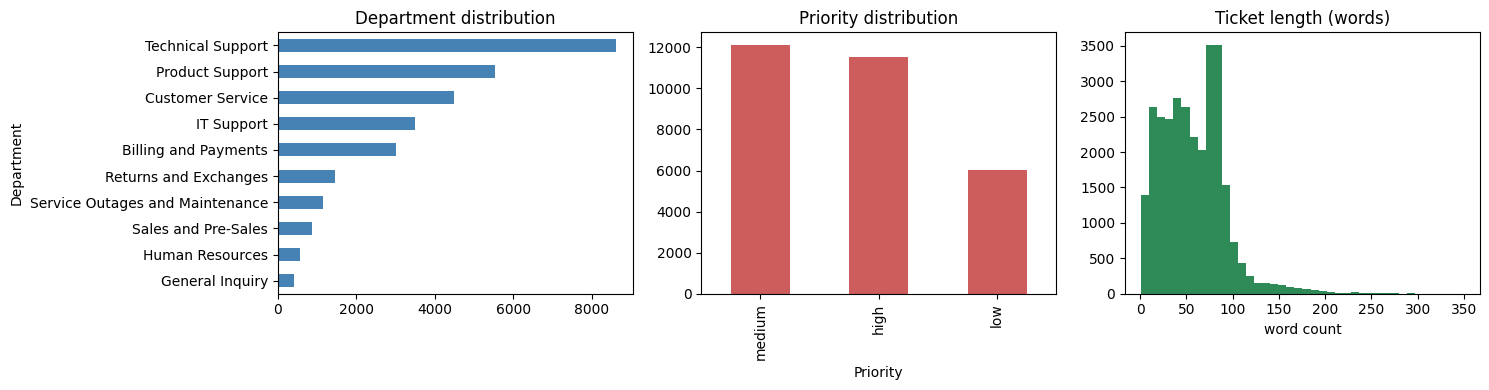

count    29650.000000
mean        57.514975
std         35.177934
min          1.000000
25%         30.000000
50%         55.000000
75%         80.000000
max        350.000000
Name: word_count, dtype: float64


In [4]:
import matplotlib.pyplot as plt

df_valid = df.dropna(subset=['Body']).copy()
df_valid['word_count'] = df_valid['Body'].str.split().apply(len)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Department'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Department distribution')
axes[0].invert_yaxis()

df['Priority'].value_counts().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Priority distribution')

axes[2].hist(df_valid['word_count'], bins=40, color='seagreen')
axes[2].set_title('Ticket length (words)')
axes[2].set_xlabel('word count')

plt.tight_layout()
plt.show()

print(df_valid['word_count'].describe())

**EDA Discussion**

The ticket lengths range from 1 to 350 words, with a median of around 55 words. This shows that most tickets are relatively short and are usually written as brief descriptions rather than long documents. This makes a TF-IDF-based approach a practical choice for representing the ticket text.

The Priority values are reasonably balanced, with medium priority being the most common, followed by high and low priority. In contrast, the department distribution is much more uneven. Technical Support, Product Support, and Customer Service together make up more than 60% of the tickets, while Human Resources and General Inquiry have much fewer examples.

This class imbalance is important when building and evaluating the models. A stratified train/test split is therefore used to maintain the department proportions in both datasets. Macro F1 is also considered alongside accuracy so that performance on smaller departments is not hidden by the larger classes. For models that support it, class_weight='balanced' is used to give greater importance to the minority classes.

**Extremely Short and Long Ticket Bodies**

Very short and very long tickets were also checked, as they may be harder for the model to classify correctly.


In [5]:
very_short = df_valid[df_valid['word_count'] <= 3]
very_long = df_valid[df_valid['word_count'] >= 250]

print('Tickets with <=3 words: %d (%.2f%% of dataset)' % (len(very_short), 100 * len(very_short) / len(df_valid)))
print('Tickets with >=250 words: %d (%.2f%% of dataset)' % (len(very_long), 100 * len(very_long) / len(df_valid)))
print()
print('Sample of very short ticket bodies:')
print(very_short['Body'].head(5).to_list())

Tickets with <=3 words: 103 (0.35% of dataset)
Tickets with >=250 words: 45 (0.15% of dataset)

Sample of very short ticket bodies:
['Requesting Assistance', 'Our system', 'Assistance Needed', 'Requesting assistance', 'Improve investment procedures']


**Discussion**

Very short tickets, such as “Please help” or “Issue with account”, contain limited information, which can make them more difficult for the model to classify correctly. On the other hand, very long tickets may describe more than one issue, meaning they could potentially relate to different departments. Both types of tickets were kept in the dataset because they are realistic examples that a real IT support system would also need to handle. These cases are therefore useful to keep in mind when looking at the model's performance and errors.


## 5. Data Cleaning

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_valid['clean_body'] = df_valid['Body'].apply(clean_text)
df_valid[['Body', 'clean_body']].head(5)

,Body,clean_body
0,"Dear Customer Support Team,I am writing to rep...",dear customer support team i am writing to rep...
1,"Dear Customer Support Team,I hope this message...",dear customer support team i hope this message...
2,"Dear Customer Support Team,I hope this message...",dear customer support team i hope this message...
3,"Dear Support Team,I hope this message reaches ...",dear support team i hope this message reaches ...
4,"Dear Customer Support,I hope this message reac...",dear customer support i hope this message reac...


Only the one ticket with a missing Body value was removed. The text cleaning was kept fairly simple: text was converted to lowercase and non-alphanumeric characters were removed to reduce unnecessary noise.

Digits were kept because technical tickets can contain useful information such as error codes and version numbers, for example 404 or 4.4. Stemming and lemmatisation were not used because technical terms and product names can be affected by changing words to their common forms. Stopword removal was handled later during TF-IDF using stop_words='english'.

## 6. Train/Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_valid['clean_body'], df_valid['Department'],
    test_size=0.2, random_state=42, stratify=df_valid['Department']
)
print('Train:', X_train.shape[0], ' Test:', X_test.shape[0])

Train: 23720  Test: 5930


**Discussion**

The data was split before fitting the TF-IDF vectoriser and the models, so the test set was kept separate and could not influence the training process. A stratified split was used to keep the department proportions similar in both the training and test sets, which is important because the dataset has an uneven class distribution. A fixed **random_state** was also used so that the same split can be reproduced.


## 7. Baseline Model

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

baseline_clf = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_clf.fit(X_train, y_train)
baseline_pred = baseline_clf.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
base_p, base_r, base_f1m, _ = precision_recall_fscore_support(y_test, baseline_pred, average='macro', zero_division=0)
_, _, base_f1w, _ = precision_recall_fscore_support(y_test, baseline_pred, average='weighted', zero_division=0)

baseline_results = pd.DataFrame([[
    'Majority-Class Baseline', baseline_acc, base_p, base_r, base_f1m, base_f1w
]], columns=['Model', 'Accuracy', 'Precision', 'Recall', 'Macro F1', 'Weighted F1'])
baseline_results.round(3)

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,Majority-Class Baseline,0.291,0.029,0.1,0.045,0.131


**Discussion**

Before training the machine learning models, a simple majority-class baseline was created. It always predicts the most common department, which is `Technical Support`. This gives us a basic reference point for judging whether the machine learning models are actually learning useful patterns from the ticket text.

The baseline can achieve reasonable accuracy because of the class imbalance, but its Macro F1 is very low because it does not correctly identify the smaller departments. This shows why accuracy alone is not enough for this project and why Macro F1 is also used when comparing the models.

The baseline does not use TF-IDF because it ignores the ticket text completely and simply predicts the most common department.


**Why this matters**

The difference between the baseline and the NLP models shows whether using the ticket text actually improves classification. Therefore, the models are compared with the baseline using Macro F1 as well as accuracy, rather than looking at accuracy alone.


## 8. Feature Extraction : TF-IDF
**Discussion**

TF-IDF gives higher importance to words that are useful for distinguishing between departments and lower importance to words that appear in many tickets. For example, words such as “invoice” or “password” can be more useful for routing than common words such as “customer” or “please”.

Stopwords and very common terms were reduced using **stop_words='english'** and **max_df=0.9**, while **min_df=3** helped remove very rare words. Both unigrams and unigrams with bigrams were tested, as bigrams can capture useful phrases such as “password reset”.

The comparison was done using stratified cross-validation on the training data only. The test set was kept separate and was used only for the final model evaluation, avoiding data leakage.


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

cv_selector = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for ngram in [(1, 1), (1, 2)]:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', min_df=3, max_df=0.9,
                                   ngram_range=ngram, sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
    cv_f1m = cross_val_score(pipe, X_train, y_train, cv=cv_selector, scoring='f1_macro', n_jobs=-1)
    print(f'ngram_range={ngram}  mean CV macro F1={cv_f1m.mean():.4f}  (+/- {cv_f1m.std():.4f})')


ngram_range=(1, 1)  mean CV macro F1=0.3949  (+/- 0.0062)
ngram_range=(1, 2)  mean CV macro F1=0.5261  (+/- 0.0012)


**Result**

The unigram + bigram approach performed better than unigrams alone based on cross-validated Macro F1 on the training data. This suggests that short phrases can provide useful information for identifying the correct department. Therefore, **ngram_range=(1,2)** was selected for the final TF-IDF representation.


**Extending the Representation Search**

After finding that unigrams and bigrams worked better together, different **min_df** values were also tested to see whether removing very rare words affected performance. The other TF-IDF settings were kept the same, and the comparison was again done using stratified cross-validation on the training data only. The test set was not used when choosing the final representation.


In [11]:
for min_df_val in [2, 3, 10]:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', min_df=min_df_val, max_df=0.9,
                                   ngram_range=(1, 2), sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
    cv_f1m = cross_val_score(pipe, X_train, y_train, cv=cv_selector, scoring='f1_macro', n_jobs=-1)
    print(f'min_df={min_df_val:>2}  mean CV macro F1={cv_f1m.mean():.4f}  (+/- {cv_f1m.std():.4f})')


min_df= 2  mean CV macro F1=0.5419  (+/- 0.0019)
min_df= 3  mean CV macro F1=0.5261  (+/- 0.0012)
min_df=10  mean CV macro F1=0.4697  (+/- 0.0015)


Result

A lower min_df keeps more rare words, while a higher value removes words that appear in only a few tickets. The value that gives the highest cross-validated Macro F1 is preferred. If the difference is small, min_df=3 is kept because it provides a simpler vocabulary without a meaningful loss in performance.

As with the earlier TF-IDF comparison, this was tested using the training data only, so the test set remains untouched.

## 9. Machine Learning Modelling
Three different models were trained using the selected TF-IDF features:

- Multinomial Naive Bayes - a simple and fast model commonly used for text classification.
- Logistic Regression - a linear model that works well with high-dimensional TF-IDF data.
- Linear SVM - another linear model that is often effective for text classification with sparse features.

class_weight='balanced' was used where supported to give more importance to the smaller departments and account for the class imbalance in the dataset.

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

vectorizer = TfidfVectorizer(stop_words='english', min_df=3, max_df=0.9,
                              ngram_range=(1, 2), sublinear_tf=True)
Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)

models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Linear SVM': LinearSVC(class_weight='balanced', max_iter=5000)
}

rows = []
fitted = {}
for name, clf in models.items():
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    fitted[name] = pred
    acc = accuracy_score(y_test, pred)
    p, r, f1m, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
    _, _, f1w, _ = precision_recall_fscore_support(y_test, pred, average='weighted', zero_division=0)
    rows.append([name, acc, p, r, f1m, f1w])

results = pd.DataFrame(rows, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'Macro F1', 'Weighted F1'])
results.round(3)

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,Multinomial Naive Bayes,0.439,0.724,0.223,0.216,0.369
1,Logistic Regression,0.574,0.557,0.634,0.585,0.575
2,Linear SVM,0.720,0.714,0.732,0.722,0.721


## 10. Model Selection

In [15]:
from sklearn.metrics import classification_report
print('Naive Bayes predicted-class distribution (illustrates majority-class collapse):')
print(pd.Series(fitted['Multinomial Naive Bayes']).value_counts().head(3))
print()
print('Linear SVM — per-department classification report:')
print(classification_report(y_test, fitted['Linear SVM'], zero_division=0))

Naive Bayes predicted-class distribution (illustrates majority-class collapse):
Technical Support    3952
Customer Service      970
Product Support       620
Name: count, dtype: int64

Linear SVM — per-department classification report:
                                 precision    recall  f1-score   support

           Billing and Payments       0.89      0.89      0.89       604
               Customer Service       0.68      0.67      0.68       896
                General Inquiry       0.66      0.70      0.68        84
                Human Resources       0.78      0.75      0.77       114
                     IT Support       0.64      0.66      0.65       700
                Product Support       0.69      0.67      0.68      1108
          Returns and Exchanges       0.70      0.75      0.73       293
            Sales and Pre-Sales       0.60      0.71      0.65       177
Service Outages and Maintenance       0.76      0.78      0.77       231
              Technical Support  

**Discussion**

Naive Bayes had the lowest Macro F1, even though its precision was relatively high. This is mainly because it made many predictions for the majority class, while recall for the smaller departments was much lower. Logistic Regression performed better overall.

Linear SVM performed best among the three models, with a Macro F1 of 0.722 before tuning. After tuning, its Macro F1 increased to 0.744 on the held-out test set. This is important because the dataset has a large class imbalance, so Macro F1 gives a better view of how the model performs across all ten departments.

The tuned Linear SVM still makes mistakes on a number of tickets, so it should not be treated as a perfect or fully automatic solution. These errors are examined in the following error analysis section.


## 11. Evaluation
Accuracy alone can be misleading because the dataset has a large class imbalance. A model could achieve reasonable accuracy while performing poorly on smaller departments.

For this reason, Macro F1 is used as the main metric because it gives equal importance to all ten departments. Weighted F1 is also reported as a secondary measure because it takes the number of tickets in each department into account.

The confusion matrix is then used to see which departments are most often confused by the final model.

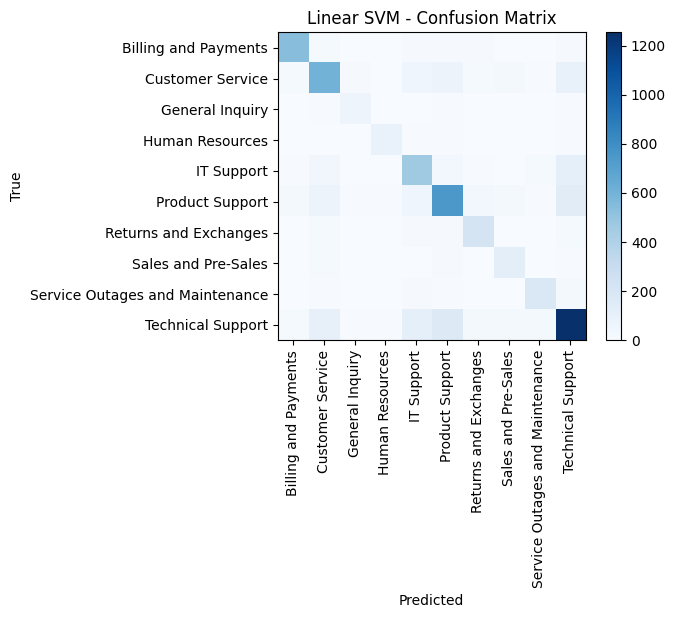

In [17]:
from sklearn.metrics import confusion_matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, fitted['Linear SVM'], labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Linear SVM - Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()

The untuned Linear SVM achieved 0.720 accuracy and 0.722 Macro F1 on the held-out test set. After tuning, performance improved to 0.739 accuracy and 0.744 Macro F1. The model performed particularly well on Billing and Payments, where terms such as invoices, charges and payments are more distinctive. Performance was weaker for Technical Support, Product Support and IT Support, where the ticket content is more similar between departments. These overlapping cases are explored in the next section.

**Department-level interpretation.** The classification report shows that **IT Support** and **Sales and Pre-Sales** had the lowest F1 scores at 0.65, followed by **Product Support, Customer Service and General Inquiry** at 0.68. IT Support is more difficult to classify because it shares technical terms such as “system”, “error” and “account” with Technical Support and Product Support. Sales and Pre-Sales is also a smaller department, and some tickets can have similar language to Product Support when they mention product-related issues. These overlaps help explain where the model has more difficulty distinguishing between departments.


**Minority-class impact.** The department sizes range from 419 tickets for General Inquiry to 8,617 for Technical Support, so the smaller departments have fewer test examples. As a result, a small number of errors can have a larger effect on their recall and F1 scores. This is one reason Macro F1 is important, as it gives equal importance to each department rather than being dominated by the larger classes. The confusion matrix also shows errors across several departments, supporting the earlier finding that some departments have overlapping language.

## 12. Hyperparameter Tuning

Tuning was limited to the strongest candidate from Section 10, the Linear SVM, to keep the search controlled and explainable. The main hyperparameter tested was the regularisation strength **C**, which controls how closely the model fits the training data. A small, stratified 3-fold cross-validation grid search was used, with **Macro F1** as the scoring metric to remain consistent with the main evaluation measure used in this project.


In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {'C': [0.1, 0.5, 1.0, 2.0, 5.0]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

svm_search = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=5000),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)
svm_search.fit(Xtr, y_train)

print('Best C (3-fold CV, macro F1):', svm_search.best_params_['C'])
print('Best CV macro F1:', round(svm_search.best_score_, 4))

tuned_svm = svm_search.best_estimator_
tuned_pred = tuned_svm.predict(Xte)

tuned_acc = accuracy_score(y_test, tuned_pred)
tp, tr, tf1m, _ = precision_recall_fscore_support(y_test, tuned_pred, average='macro', zero_division=0)
_, _, tf1w, _ = precision_recall_fscore_support(y_test, tuned_pred, average='weighted', zero_division=0)
print(f'Tuned SVM on held-out test set — Accuracy: {tuned_acc:.3f}  Macro F1: {tf1m:.3f}  Weighted F1: {tf1w:.3f}')

Best C (3-fold CV, macro F1): 5.0
Best CV macro F1: 0.6801
Tuned SVM on held-out test set — Accuracy: 0.739  Macro F1: 0.744  Weighted F1: 0.739


**Result.** The best value of **C** was **5.0**, compared with the default **C=1.0**. The tuned Linear SVM improved Macro F1 from **0.722 to 0.744** on the held-out test set, so the tuned configuration was retained as the final model.


## 13. Final Model and Results Summary
The table below summarises all configurations evaluated on the same held-out test set: the majority-class baseline, the three default NLP models, and the tuned Linear SVM. This provides a direct comparison of their performance using the same evaluation metrics.


In [19]:
final_results = pd.concat([
    baseline_results,
    results,
    pd.DataFrame([['Linear SVM (Tuned)', tuned_acc, tp, tr, tf1m, tf1w]], columns=results.columns)
], ignore_index=True)

final_results_sorted = final_results.sort_values('Macro F1', ascending=False).reset_index(drop=True)
final_results_sorted.round(3)

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,Linear SVM (Tuned),0.739,0.757,0.732,0.744,0.739
1,Linear SVM,0.720,0.714,0.732,0.722,0.721
2,Logistic Regression,0.574,0.557,0.634,0.585,0.575
3,Multinomial Naive Bayes,0.439,0.724,0.223,0.216,0.369
4,Majority-Class Baseline,0.291,0.029,0.100,0.045,0.131


**Final model selection.** The tuned **Linear SVM** has the highest Macro F1 in the table, with a score of **0.744**, so it was selected as the final model. This follows the use of Macro F1 as the primary metric because the departments are unevenly distributed. Compared with the majority-class baseline, the final model shows that using NLP-based classification provides a substantial improvement over simply predicting the most common department.


## 14. Error Analysis

In [20]:
import random
random.seed(1)

pred_svm = fitted['Linear SVM']
y_test_reset = y_test.reset_index(drop=True)
orig_body = df_valid.loc[X_test.index, 'Body'].reset_index(drop=True)

# top confused department pairs
confusions = []
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        if i != j and cm[i, j] > 0:
            confusions.append((a, b, cm[i, j]))
confusions.sort(key=lambda x: -x[2])
print('Top confused department pairs:')
for c in confusions[:5]:
    print(' ', c)

print()
mis_idx = np.where(pred_svm != y_test_reset.values)[0]
print('Misclassified tickets: %d / %d (%.1f%%)' % (len(mis_idx), len(y_test_reset), 100*len(mis_idx)/len(y_test_reset)))
for i in random.sample(list(mis_idx), 3):
    print('---')
    print('TRUE:', y_test_reset[i], '| PRED:', pred_svm[i])
    print('TEXT:', orig_body[i][:160], '...')

Top confused department pairs:
  ('Technical Support', 'Product Support', np.int64(164))
  ('Product Support', 'Technical Support', np.int64(141))
  ('IT Support', 'Technical Support', np.int64(117))
  ('Technical Support', 'IT Support', np.int64(108))
  ('Technical Support', 'Customer Service', np.int64(101))

Misclassified tickets: 1658 / 5930 (28.0%)
---
TRUE: Product Support | PRED: Sales and Pre-Sales
TEXT: The data analytics platform encountered a failure, causing disruptions in the investment optimization procedures. ...
---
TRUE: Technical Support | PRED: Customer Service
TEXT: Is it possible to get some insights into effective digital marketing strategies for product promotion? Thank you! ...
---
TRUE: Billing and Payments | PRED: Returns and Exchanges
TEXT: An incident involving data occurred; passwords have been updated and a system audit has been performed. ...


**What the errors reveal.** The largest confusions occur between **Technical Support, Product Support, IT Support and Customer Service**, where tickets often share terms such as software, accounts, systems and errors. Some misclassified tickets are also short or ambiguous, making them difficult to assign to a single department. A small number of conflicting duplicate labels identified earlier may also contribute to these errors. Overall, the results suggest that some classification errors are related to overlap and ambiguity in the source data, rather than being caused only by the model.


## 15. Feature Interpretability

Linear SVM assigns a weight to each TF-IDF term for every department. Terms with the highest positive weights have the strongest influence on predicting that department. These terms were extracted directly from the fitted tuned model rather than selected manually, helping to check whether the model learned meaningful department-related vocabulary such as **VPN, invoice and password**.


In [21]:
feature_names = np.array(vectorizer.get_feature_names_out())
svm_classes = tuned_svm.classes_
top_n = 8

print('Top TF-IDF terms by department (final tuned Linear SVM):')
for dept, coef_row in zip(svm_classes, tuned_svm.coef_):
    top_idx = np.argsort(coef_row)[-top_n:][::-1]
    top_terms = feature_names[top_idx]
    print(f'{dept:25s} -> {", ".join(top_terms)}')

Top TF-IDF terms by department (final tuned Linear SVM):
Billing and Payments      -> billing, payment, invoice, invoices, charges, redis postgresql, systems using, guides tutorials
Customer Service          -> offer data, customers looking, anticipated growth, integrations microsoft, data server, attention needed, mongodb version, integrating jira
General Inquiry           -> details optimize, possible data, problems server, analytics optimize, implementing digital, solutions healthcare, need assistance, better optimize
Human Resources           -> employee, hr, human, detected security, crash investment, systems security, inkscape, gaming products
IT Support                -> data thank, overview digital, compromised owing, causing crash, report security, attempts sql, analysis process, router verifying
Product Support           -> management services, attempts systems, growth integration, rebooted updates, request implement, information despite, available brand, data laravel
Returns

**Interpretation.** The extracted terms should be checked for whether they make sense for each department. For example, billing-related terms for **Billing and Payments** or connectivity terms for **Technical Support** would suggest that the model has learned useful routing patterns. Unexpected or noisy terms may indicate that the model is relying on patterns specific to this dataset, which is an important limitation to consider.


## 16. Business Interpretation
```
User submits ticket -> NLP system analyses ticket -> Department predicted
   -> Ticket routed automatically -> Human support team handles ticket
```
Based on the **0.739 held-out accuracy** and the error patterns, the system is better suited to **decision support than fully autonomous routing**. High-confidence predictions could be routed automatically, while low-confidence predictions, particularly within the overlapping technical departments, could be flagged for human review. This keeps a human in the loop where the model is less reliable.


## 17. Strengths and Limitations
**Strengths:** The pipeline is simple and interpretable, with TF-IDF and linear models providing a practical approach for regular retraining. Three models were compared empirically rather than assuming one would perform best. The use of a fixed split and random state also makes the results reproducible, while the approach maps directly to a realistic helpdesk workflow.

**Limitations:** The 20:1 class imbalance still affects performance on smaller departments despite using balanced class weights and Macro F1. Some labels are ambiguous or inconsistent, and TF-IDF does not capture context in the same way as modern transformer-based models. The dataset is also a static, externally sourced snapshot, so terminology may change over time and its representativeness of a specific organisation cannot be guaranteed. Performance should therefore be validated on an organisation's own tickets before deployment.


## 18. Ethical and Practical Considerations
**Automating decisions that affect people.** Department routing can affect how quickly a support issue is handled. The classifier should therefore suggest a department rather than automatically and permanently reassigning tickets, with human review available for uncertain predictions.

**Sensitive information in ticket text.** Support tickets may contain personal or sensitive information. In a production system, identifiable information should be masked or redacted where appropriate, and access to raw ticket text should be limited to authorised users.

**Bias from historical labels.** The Department labels reflect the organisation's existing support structure and may not always represent an objective classification. If historical routing decisions were inconsistent or biased, a model trained on those labels may reproduce those patterns.

**Monitoring after deployment.** Ticket vocabulary and support structures can change over time. Model predictions should therefore be periodically reviewed against human-confirmed outcomes, with retraining considered when performance decreases.


## 19. Data-Driven Recommendations
1. Use the tuned Linear SVM as decision support within the ticketing system rather than a fully silent auto-router, given its 0.739 held-out test accuracy.
2. Send low-confidence predictions for human review, particularly for the overlapping Technical Support, Product Support, IT Support and Customer Service departments.
3. Collect more labelled tickets for smaller departments, especially General Inquiry, Human Resources and Sales and Pre-Sales, to give the model more examples to learn from.
4. Periodically audit and relabel tickets to identify and reduce inconsistent or noisy department labels.
5. Retrain the model regularly as products, software and support terminology change over time.


## 20. Conclusion
This project addressed IT support ticket triage as a supervised multiclass text classification problem using 29,651 tickets. Among the three models tested, the **TF-IDF (unigram + bigram) with Linear SVM** achieved the strongest overall performance, with **0.739 accuracy and 0.744 Macro F1** on the held-out test set.

The results show that NLP can provide useful support for automated ticket routing, although some departments remain difficult to distinguish because of overlapping language and ambiguous labels. The system should therefore be used as **decision support rather than a complete replacement for human triage**. A human-in-the-loop approach, confidence-based review and additional labelled data for smaller departments are recommended for future improvement.


## 21. References
Joachims, T. (1998) ‘Text categorization with support vector machines: Learning with many relevant features’, in Proceedings of the European Conference on Machine Learning (ECML), pp. 137–142.

Patil, P. (n.d.) *IT Support Ticket Data* [Dataset]. Kaggle. Available at: https://www.kaggle.com/datasets/parthpatil8858/it-support-ticket-data (Accessed: 3 September 2026).

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, E. (2011) ‘Scikit-learn: Machine Learning in Python’, Journal of Machine Learning Research, 12, pp. 2825–2830.

Salton, G. and Buckley, C. (1988) ‘Term-weighting approaches in automatic text retrieval’, Information Processing & Management, 24(5), pp. 513–523.

Scikit-learn (2026) ‘LinearSVC’. Scikit-learn documentation. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html (Accessed: 16 September 2026).

Scikit-learn (2026) ‘TfidfVectorizer’. Scikit-learn documentation. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html (Accessed: 16 September 2026).